# EDA — 입찰 공고 데이터 (data_list.csv)

**데이터 경로:** `/home/shared/data_list.csv`  
**파일 문서:** `/home/shared/files/` (HWP/PDF 원문)

## 컬럼 설명
| 컬럼 | 설명 |
|---|---|
| 공고 번호 | 입찰 공고 고유 번호 |
| 공고 차수 | 공고 회차 (재공고 등) |
| 사업명 | 사업 제목 |
| 사업 금액 | 사업 예산 (원) |
| 발주 기관 | 발주 기관명 |
| 공개 일자 | 공고 공개 일시 |
| 입찰 참여 시작일 | 입찰 접수 시작 |
| 입찰 참여 마감일 | 입찰 접수 마감 |
| 사업 요약 | LLM 생성 사업 요약 |
| 파일형식 | hwp / pdf |
| 파일명 | 원문 파일명 |
| 텍스트 | 원문 추출 텍스트 |

## 0. 라이브러리 임포트

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rc
import re
from collections import Counter

rc('font', family='NanumGothic')  # 한글 폰트 (없으면 아래 주석 해제)
# plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '/home/shared/data_list.csv'
print('Libraries loaded.')

Libraries loaded.


## 1. 데이터 로드 & 기본 확인

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (100, 12)


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...


In [3]:
df.dtypes

공고 번호            str
공고 차수        float64
사업명              str
사업 금액        float64
발주 기관            str
공개 일자            str
입찰 참여 시작일        str
입찰 참여 마감일        str
사업 요약            str
파일형식             str
파일명              str
텍스트              str
dtype: object

In [4]:
# 날짜 컬럼 파싱
for col in ['공개 일자', '입찰 참여 시작일', '입찰 참여 마감일']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print('날짜 범위 (공개 일자):', df['공개 일자'].min(), '~', df['공개 일자'].max())
df.dtypes

날짜 범위 (공개 일자): 2021-10-08 00:00:00 ~ 2025-02-11 13:32:46


공고 번호                   str
공고 차수               float64
사업명                     str
사업 금액               float64
발주 기관                   str
공개 일자        datetime64[us]
입찰 참여 시작일    datetime64[us]
입찰 참여 마감일    datetime64[us]
사업 요약                   str
파일형식                    str
파일명                     str
텍스트                     str
dtype: object

## 2. 결측치 분석

In [5]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
null_df = pd.DataFrame({'결측 수': null_counts, '결측률(%)': null_pct})
null_df[null_df['결측 수'] > 0]

,결측 수,결측률(%)
공고 번호,18,18.0
공고 차수,18,18.0
사업 금액,1,1.0
입찰 참여 시작일,26,26.0
입찰 참여 마감일,8,8.0


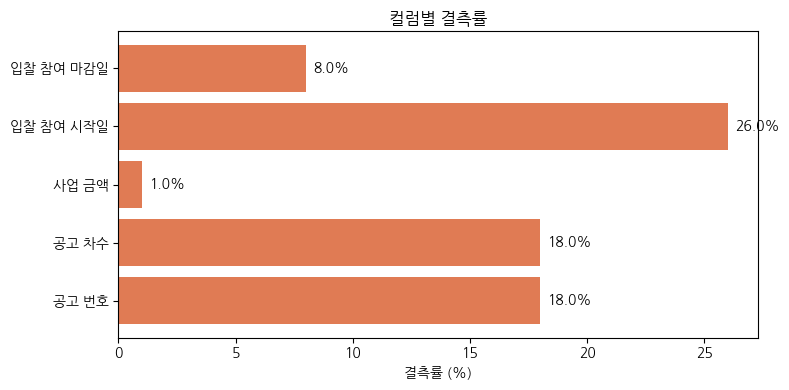

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
cols_with_null = null_df[null_df['결측 수'] > 0].index.tolist()
ax.barh(cols_with_null, null_df.loc[cols_with_null, '결측률(%)'], color='#e07b54')
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측률')
for i, v in enumerate(null_df.loc[cols_with_null, '결측률(%)']):
    ax.text(v + 0.3, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

## 3. 사업 금액 분포

In [7]:
amt = df['사업 금액'].dropna()
print(f'건수: {len(amt)}')
print(f'평균: {amt.mean()/1e8:.2f}억')
print(f'중앙값: {amt.median()/1e8:.2f}억')
print(f'최소: {amt.min()/1e6:.0f}백만')
print(f'최대: {amt.max()/1e8:.1f}억')
print(f'표준편차: {amt.std()/1e8:.2f}억')

건수: 99
평균: 6.91억
중앙값: 1.73억
최소: 0백만
최대: 141.1억
표준편차: 19.67억


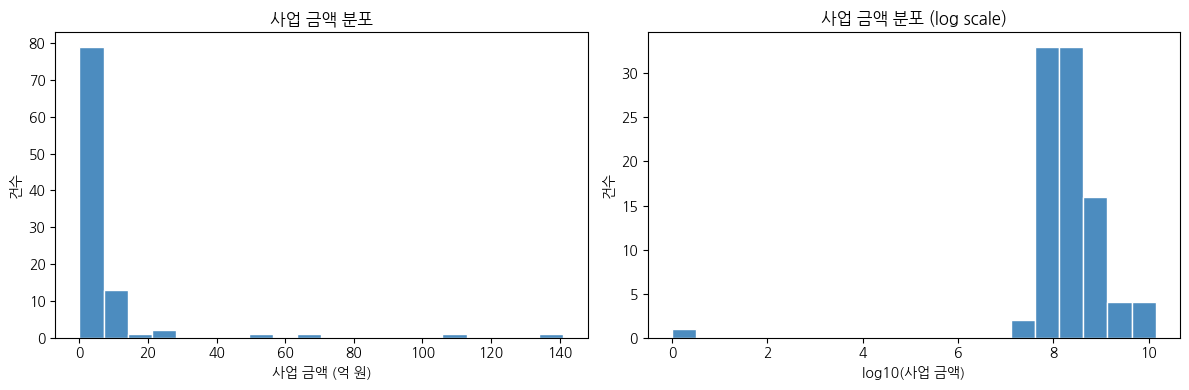

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 원 단위 히스토그램
axes[0].hist(amt / 1e8, bins=20, color='#4c8cbf', edgecolor='white')
axes[0].set_xlabel('사업 금액 (억 원)')
axes[0].set_ylabel('건수')
axes[0].set_title('사업 금액 분포')

# 로그 스케일
axes[1].hist(np.log10(amt[amt > 0]), bins=20, color='#4c8cbf', edgecolor='white')
axes[1].set_xlabel('log10(사업 금액)')
axes[1].set_ylabel('건수')
axes[1].set_title('사업 금액 분포 (log scale)')

plt.tight_layout()
plt.show()

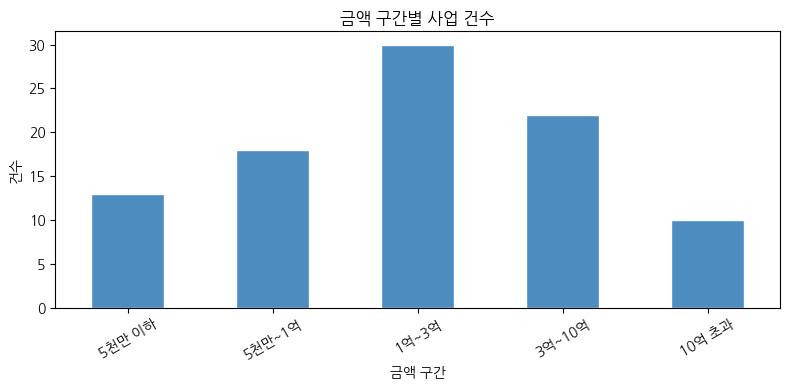

In [9]:
# 금액 구간별 분류
bins = [0, 5e7, 1e8, 3e8, 1e9, float('inf')]
labels = ['5천만 이하', '5천만~1억', '1억~3억', '3억~10억', '10억 초과']
df['금액 구간'] = pd.cut(df['사업 금액'], bins=bins, labels=labels)
df['금액 구간'].value_counts().sort_index().plot(kind='bar', color='#4c8cbf', edgecolor='white', figsize=(8, 4))
plt.title('금액 구간별 사업 건수')
plt.xlabel('금액 구간')
plt.ylabel('건수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. 파일 형식 분포

파일형식
hwp    96
pdf     4
Name: count, dtype: int64


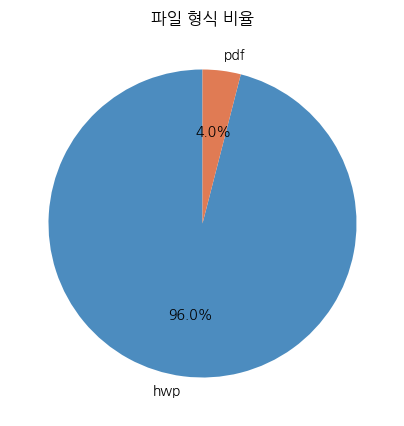

In [10]:
fmt_counts = df['파일형식'].value_counts()
print(fmt_counts)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(fmt_counts, labels=fmt_counts.index, autopct='%1.1f%%',
       colors=['#4c8cbf', '#e07b54'], startangle=90)
ax.set_title('파일 형식 비율')
plt.show()

## 5. 발주 기관 분석

In [11]:
org_counts = df['발주 기관'].value_counts()
print(f'고유 발주 기관 수: {len(org_counts)}')
print('\n상위 10개 발주 기관:')
print(org_counts.head(10))

고유 발주 기관 수: 87

상위 10개 발주 기관:
발주 기관
한국수자원공사        3
한국철도공사 (용역)    3
한국연구재단         2
한국생산기술연구원      2
인천광역시          2
국방과학연구소        2
수협중앙회          2
한국농어촌공사        2
축산물품질평가원       2
광주과학기술원        2
Name: count, dtype: int64


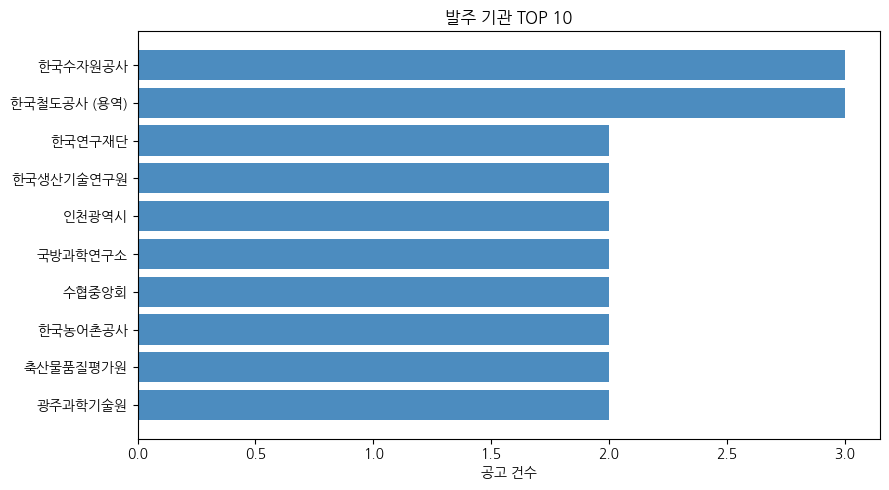

In [12]:
top10 = org_counts.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10.index[::-1], top10.values[::-1], color='#4c8cbf')
ax.set_xlabel('공고 건수')
ax.set_title('발주 기관 TOP 10')
plt.tight_layout()
plt.show()

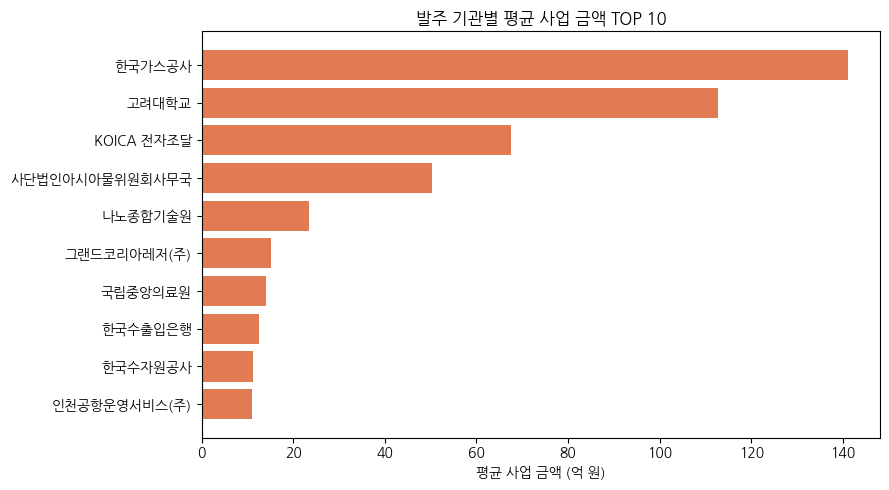

In [13]:
# 발주 기관별 평균 사업 금액
org_amt = df.groupby('발주 기관')['사업 금액'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(org_amt.index[::-1], org_amt.values[::-1] / 1e8, color='#e07b54')
ax.set_xlabel('평균 사업 금액 (억 원)')
ax.set_title('발주 기관별 평균 사업 금액 TOP 10')
plt.tight_layout()
plt.show()

## 6. 시계열 분석 (공개 일자)

In [14]:
df_dated = df.dropna(subset=['공개 일자'])
df_dated = df_dated.copy()
df_dated['연도'] = df_dated['공개 일자'].dt.year
df_dated['연월'] = df_dated['공개 일자'].dt.to_period('M')

yearly = df_dated['연도'].value_counts().sort_index()
print('연도별 공고 건수:')
print(yearly)

연도별 공고 건수:
연도
2021     1
2023     1
2024    89
2025     9
Name: count, dtype: int64


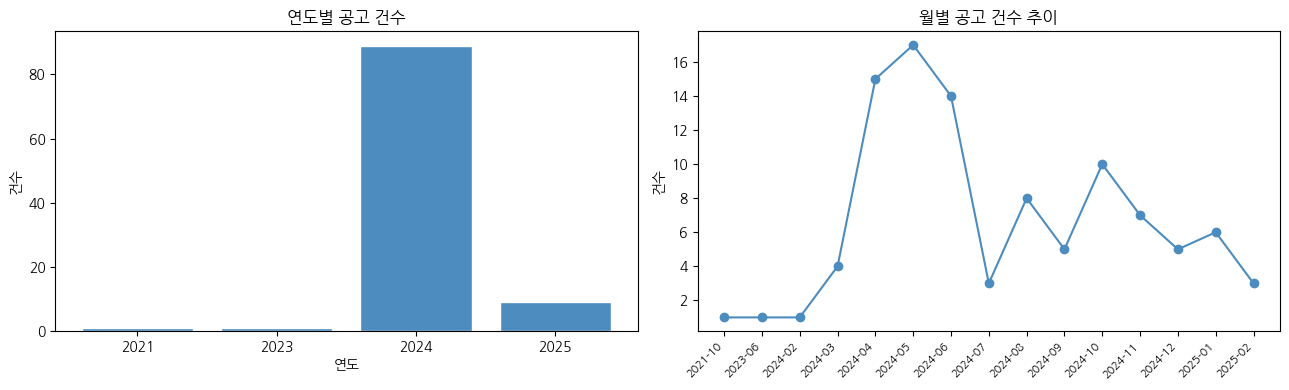

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 연도별
axes[0].bar(yearly.index.astype(str), yearly.values, color='#4c8cbf', edgecolor='white')
axes[0].set_title('연도별 공고 건수')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('건수')

# 월별 추이
monthly = df_dated.groupby('연월').size()
x_labels = [str(p) for p in monthly.index]
axes[1].plot(range(len(monthly)), monthly.values, marker='o', color='#4c8cbf')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_title('월별 공고 건수 추이')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.show()

## 7. 입찰 기간 분석

In [16]:
df_bid = df.dropna(subset=['입찰 참여 시작일', '입찰 참여 마감일']).copy()
df_bid['입찰 기간(일)'] = (df_bid['입찰 참여 마감일'] - df_bid['입찰 참여 시작일']).dt.days
df_bid['공고-시작 간격(일)'] = (df_bid['입찰 참여 시작일'] - df_bid['공개 일자']).dt.days

print('입찰 기간 통계 (일):')
print(df_bid['입찰 기간(일)'].describe().round(1))

입찰 기간 통계 (일):
count    74.0
mean      9.5
std       9.1
min       0.0
25%       4.0
50%       7.0
75%      12.0
max      45.0
Name: 입찰 기간(일), dtype: float64


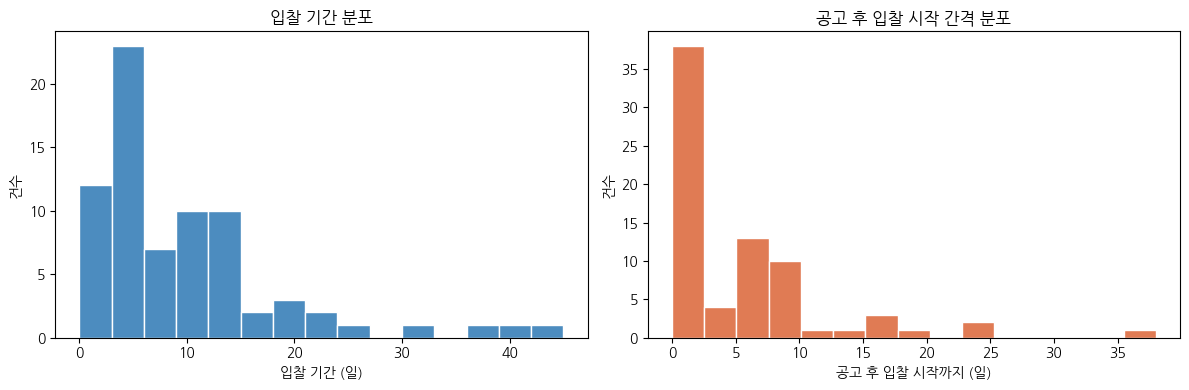

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_bid['입찰 기간(일)'].dropna(), bins=15, color='#4c8cbf', edgecolor='white')
axes[0].set_xlabel('입찰 기간 (일)')
axes[0].set_ylabel('건수')
axes[0].set_title('입찰 기간 분포')

axes[1].hist(df_bid['공고-시작 간격(일)'].dropna(), bins=15, color='#e07b54', edgecolor='white')
axes[1].set_xlabel('공고 후 입찰 시작까지 (일)')
axes[1].set_ylabel('건수')
axes[1].set_title('공고 후 입찰 시작 간격 분포')

plt.tight_layout()
plt.show()

## 8. 텍스트 길이 분석

In [18]:
df['텍스트_길이'] = df['텍스트'].str.len()
df['요약_길이'] = df['사업 요약'].str.len()
df['사업명_길이'] = df['사업명'].str.len()

print('텍스트 길이 통계:')
print(df[['텍스트_길이', '요약_길이', '사업명_길이']].describe().round(0))

텍스트 길이 통계:
        텍스트_길이  요약_길이  사업명_길이
count    100.0  100.0   100.0
mean    3844.0  269.0    30.0
std     3693.0   73.0    10.0
min       89.0  142.0    12.0
25%     1198.0  220.0    22.0
50%     2583.0  250.0    29.0
75%     5842.0  297.0    35.0
max    18335.0  524.0    65.0


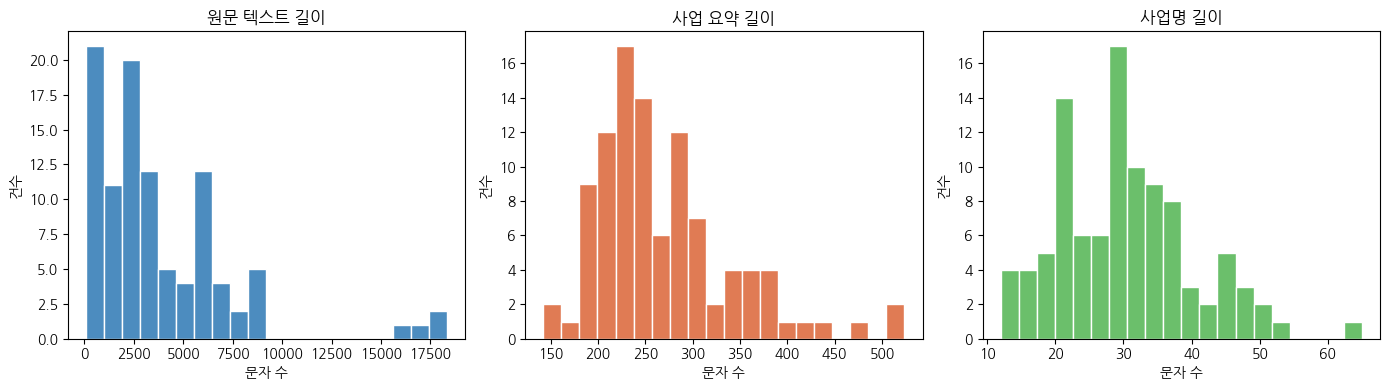

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title, color in zip(
    axes,
    ['텍스트_길이', '요약_길이', '사업명_길이'],
    ['원문 텍스트 길이', '사업 요약 길이', '사업명 길이'],
    ['#4c8cbf', '#e07b54', '#6bbf6b']
):
    ax.hist(df[col].dropna(), bins=20, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('문자 수')
    ax.set_ylabel('건수')

plt.tight_layout()
plt.show()

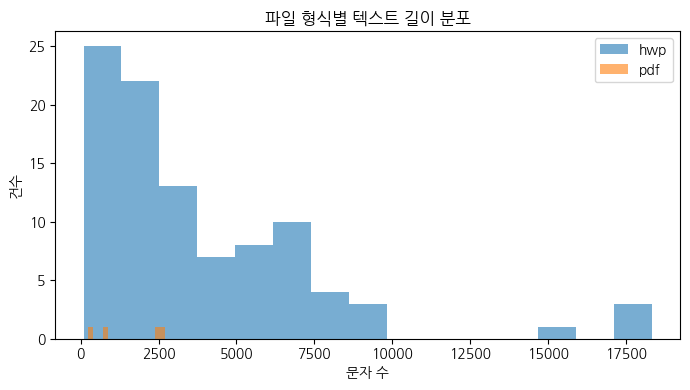

In [20]:
# 파일 형식별 텍스트 길이 비교
fig, ax = plt.subplots(figsize=(7, 4))
for fmt, grp in df.groupby('파일형식'):
    ax.hist(grp['텍스트_길이'].dropna(), bins=15, alpha=0.6, label=fmt)
ax.set_title('파일 형식별 텍스트 길이 분포')
ax.set_xlabel('문자 수')
ax.set_ylabel('건수')
ax.legend()
plt.tight_layout()
plt.show()

## 9. 사업명 키워드 분석

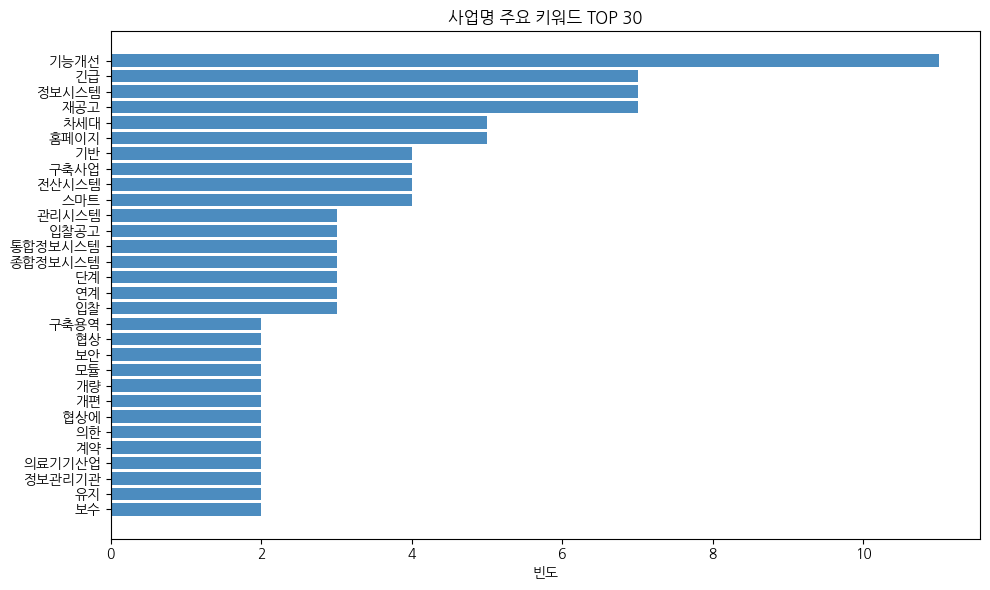

In [21]:
# 사업명에서 2글자 이상 명사 키워드 추출 (간단한 토큰화)
stopwords = {'구축', '용역', '사업', '시스템', '운영', '개발', '고도화', '기능', '정보', '및', '관련', 
             '관리', '서비스', '지원', '개선', '년', '년도', '위한', '대한', '에서', '통합', '수립'}

all_words = []
for name in df['사업명']:
    tokens = re.findall(r'[가-힣]{2,}', str(name))
    all_words.extend([t for t in tokens if t not in stopwords])

word_freq = Counter(all_words).most_common(30)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(words)[::-1], list(freqs)[::-1], color='#4c8cbf')
ax.set_title('사업명 주요 키워드 TOP 30')
ax.set_xlabel('빈도')
plt.tight_layout()
plt.show()

## 10. 사업 요약 분석

In [22]:
# 요약 내 항목(줄) 수 = '-' 로 시작하는 줄 개수
df['요약_항목수'] = df['사업 요약'].apply(
    lambda x: len([l for l in str(x).split('\n') if l.strip().startswith('-')])
)
print('요약 항목 수 통계:')
print(df['요약_항목수'].describe().round(1))

요약 항목 수 통계:
count    100.0
mean       4.9
std        1.0
min        0.0
25%        5.0
50%        5.0
75%        5.0
max        9.0
Name: 요약_항목수, dtype: float64


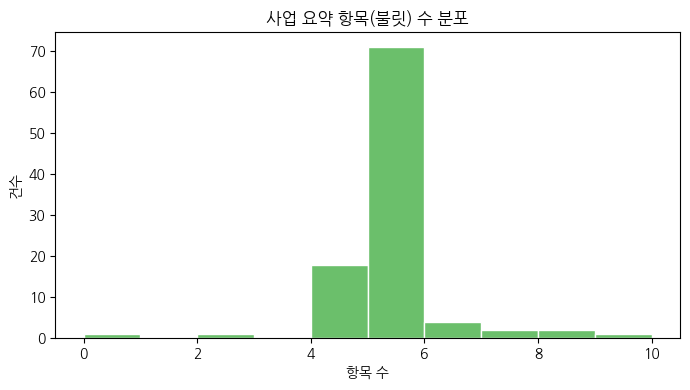

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['요약_항목수'], bins=range(0, df['요약_항목수'].max() + 2), color='#6bbf6b', edgecolor='white')
ax.set_title('사업 요약 항목(불릿) 수 분포')
ax.set_xlabel('항목 수')
ax.set_ylabel('건수')
plt.tight_layout()
plt.show()

## 11. 공고 차수 분석 (재공고 여부)

In [24]:
차수_counts = df['공고 차수'].value_counts().sort_index()
print('공고 차수 분포:')
print(차수_counts)

df['재공고'] = df['공고 차수'].apply(lambda x: '재공고' if x > 0 else '최초공고')
print('\n재공고 여부:')
print(df['재공고'].value_counts())

공고 차수 분포:
공고 차수
0.0    76
1.0     4
2.0     2
Name: count, dtype: int64

재공고 여부:
재공고
최초공고    94
재공고      6
Name: count, dtype: int64


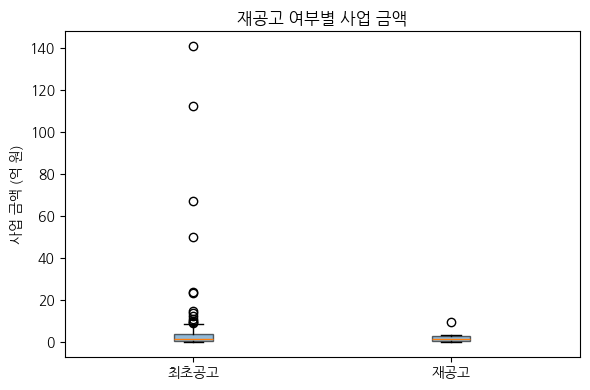

In [25]:
# 재공고 여부별 사업 금액 비교
fig, ax = plt.subplots(figsize=(6, 4))
groups = [df[df['재공고'] == g]['사업 금액'].dropna() / 1e8 for g in ['최초공고', '재공고']]
ax.boxplot(groups, labels=['최초공고', '재공고'], patch_artist=True,
           boxprops=dict(facecolor='#4c8cbf', alpha=0.6))
ax.set_ylabel('사업 금액 (억 원)')
ax.set_title('재공고 여부별 사업 금액')
plt.tight_layout()
plt.show()

## 12. 주요 인사이트 정리

In [26]:
print('='*55)
print('주요 인사이트')
print('='*55)
print(f'총 공고 건수          : {len(df):,}건')
print(f'고유 발주 기관 수     : {df["발주 기관"].nunique()}개')
print(f'평균 사업 금액        : {df["사업 금액"].mean()/1e8:.2f}억 원')
print(f'중앙값 사업 금액      : {df["사업 금액"].median()/1e8:.2f}억 원')
print(f'HWP 비율              : {(df["파일형식"]=="hwp").mean()*100:.1f}%')
print(f'결측 공고 번호 비율   : {df["공고 번호"].isnull().mean()*100:.1f}%')
print(f'입찰 시작일 결측 비율 : {df["입찰 참여 시작일"].isnull().mean()*100:.1f}%')
print(f'평균 텍스트 길이      : {df["텍스트_길이"].mean():,.0f}자')
if '입찰 기간(일)' in df_bid.columns:
    print(f'평균 입찰 기간        : {df_bid["입찰 기간(일)"].mean():.1f}일')
print('='*55)

주요 인사이트
총 공고 건수          : 100건
고유 발주 기관 수     : 87개
평균 사업 금액        : 6.91억 원
중앙값 사업 금액      : 1.73억 원
HWP 비율              : 96.0%
결측 공고 번호 비율   : 18.0%
입찰 시작일 결측 비율 : 26.0%
평균 텍스트 길이      : 3,844자
평균 입찰 기간        : 9.5일
